In [1]:
from pathlib import Path

import kagglehub
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.compose import (
    ColumnTransformer,
)
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import ElasticNet, Lasso, LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, root_mean_squared_error
from sklearn.model_selection import (
    GridSearchCV,
    RandomizedSearchCV,
    RepeatedKFold,
    train_test_split,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    FunctionTransformer,
    KBinsDiscretizer,
    MinMaxScaler,
    OneHotEncoder,
    RobustScaler,
    StandardScaler,
)

from eda_util import display_dataset_info, set_global_seed

random_state = 42
set_global_seed(random_state)

In [2]:
path = kagglehub.dataset_download("salvatorerastelli/spotify-and-youtube")
df = pd.read_csv(Path(path) / "Spotify_Youtube.csv", index_col=0)
print(f"Размер датасета: {df.shape}")

Размер датасета: (20718, 27)


# Очистка датасета

Удалим признаки, которые не относятся к нашей задаче. Или не несут в себе полезную информацию (например url, uri)

In [3]:
df.drop(
    [
        "Url_spotify",
        "Url_youtube",
        "Uri",
        "Title",
        "Channel",
        "Description",
        "Licensed",
        "official_video",
        "Likes",
        "Views",
        "Comments",
    ],
    axis=1,
    inplace=True,
)
df.columns

Index(['Artist', 'Track', 'Album', 'Album_type', 'Danceability', 'Energy',
       'Key', 'Loudness', 'Speechiness', 'Acousticness', 'Instrumentalness',
       'Liveness', 'Valence', 'Tempo', 'Duration_ms', 'Stream'],
      dtype='object')

Так как анализ показал, что признаки "Track", "Album", "Artist" имеют очень высокую кардинальность и очень высокую корреляцию с целевой переменной, то мы их удалим.

In [4]:
df.drop(
    ["Track", "Album", "Artist"],
    axis=1,
    inplace=True,
)
df.columns

Index(['Album_type', 'Danceability', 'Energy', 'Key', 'Loudness',
       'Speechiness', 'Acousticness', 'Instrumentalness', 'Liveness',
       'Valence', 'Tempo', 'Duration_ms', 'Stream'],
      dtype='object')

Так как анализ показал, что записи с `Tempo` равным 0 предположительно являются ошибками детекции, и их не большое количество относительно общего числа записей, то мы их удалим. 

In [5]:
df[df["Tempo"] == 0].describe()

,Danceability,Energy,Key,Loudness,Speechiness,Acousticness,Instrumentalness,Liveness,Valence,Tempo,Duration_ms,Stream
count,17.0,17.000000,17.000000,17.000000,17.0,17.000000,17.000000,17.000000,17.0,17.0,17.000000,1.700000e+01
mean,0.0,0.140519,5.294118,-21.128529,0.0,0.648890,0.849858,0.324576,0.0,0.0,126910.705882,1.495189e+08
std,0.0,0.230172,4.027479,6.750239,0.0,0.398952,0.322276,0.307311,0.0,0.0,123603.373341,3.060849e+08
min,0.0,0.000055,0.000000,-28.460000,0.0,0.004170,0.001140,0.095800,0.0,0.0,62850.000000,1.995393e+06
25%,0.0,0.001250,1.000000,-27.592000,0.0,0.153000,0.878000,0.111000,0.0,0.0,72223.000000,1.511033e+07
50%,0.0,0.003420,7.000000,-21.995000,0.0,0.842000,0.999000,0.114000,0.0,0.0,93452.000000,2.667729e+07
75%,0.0,0.251000,9.000000,-16.469000,0.0,0.921000,1.000000,0.603000,0.0,0.0,108527.000000,7.157121e+07
max,0.0,0.802000,10.000000,-7.977000,0.0,0.994000,1.000000,0.897000,0.0,0.0,593754.000000,9.564357e+08


In [6]:
df = df.drop(df[df["Tempo"] == 0].index)

Также удалим строки с пропущенными значениями `Stream`, так как это целевая переменная, и количество таких строк не является большим.

In [7]:
df[df["Stream"].isnull()].shape

(576, 13)

In [8]:
df = df.dropna(subset=["Stream"])

Также удалим две записи у которых много отсутствующих признаков. (см. exploration.ipynb)

In [9]:
df = df.drop(
    [11890, 13843],
)

In [10]:
display_dataset_info(df)

## Dataset info:
**Duplicate rows:** 1654 | 8.22%
## Dataset column info:
| Column           | Type    |   Non-null values |   Unique values | Missing values   | Top values                                                          |
|:-----------------|:--------|------------------:|----------------:|:-----------------|:--------------------------------------------------------------------|
| Acousticness     | float64 |             20123 |            3104 | 0 (0.00%)        | min=0.00, max=1.00, mean=0.29, std=0.29                             |
| Album_type       | object  |             20123 |               3 | 0 (0.00%)        | album (14541 rows, 72.3%)                                           |
| Danceability     | float64 |             20123 |             896 | 0 (0.00%)        | min=0.05, max=0.97, mean=0.62, std=0.16                             |
| Duration_ms      | float64 |             20123 |           14346 | 0 (0.00%)        | min=30985.00, max=4676058.00, mean=224519.19, std=125787.27         |
| Energy           | float64 |             20123 |            1255 | 0 (0.00%)        | min=0.00, max=1.00, mean=0.64, std=0.21                             |
| Instrumentalness | float64 |             20123 |            3951 | 0 (0.00%)        | min=0.00, max=0.99, mean=0.05, std=0.19                             |
| Key              | float64 |             20123 |              12 | 0 (0.00%)        | min=0.00, max=11.00, mean=5.29, std=3.58                            |
| Liveness         | float64 |             20123 |            1530 | 0 (0.00%)        | min=0.01, max=1.00, mean=0.19, std=0.17                             |
| Loudness         | float64 |             20123 |            9246 | 0 (0.00%)        | min=-46.25, max=0.92, mean=-7.63, std=4.62                          |
| Speechiness      | float64 |             20123 |            1266 | 0 (0.00%)        | min=0.02, max=0.96, mean=0.10, std=0.11                             |
| Stream           | float64 |             20123 |           18446 | 0 (0.00%)        | min=6574.00, max=3386520288.00, mean=135931520.92, std=244094367.20 |
| Tempo            | float64 |             20123 |           14627 | 0 (0.00%)        | min=37.11, max=243.37, mean=120.73, std=29.41                       |
| Valence          | float64 |             20123 |            1287 | 0 (0.00%)        | min=0.00, max=0.99, mean=0.53, std=0.24                             |

Сохраним полученный датасет в csv файл, чтобы мы могли использовать его в дальнейшем. (Можно скачать через git lfs)

In [11]:
df.to_csv("../data/cleaned_data.csv", index=False)

# Разбиение датасета на тренировочную/тестовую выборки

In [12]:
df = pd.read_csv("../data/cleaned_data.csv")

In [13]:
df["Stream"].describe()

count    2.012300e+04
mean     1.359315e+08
std      2.440944e+08
min      6.574000e+03
25%      1.767508e+07
50%      4.968602e+07
75%      1.383986e+08
max      3.386520e+09
Name: Stream, dtype: float64

In [14]:
# Stratify by binned target using KBinsDiscretizer
y = df["Stream"]
discretizer = KBinsDiscretizer(
    n_bins=20, encode="ordinal", strategy="quantile"
)
y_bins = (
    discretizer.fit_transform(y.to_numpy().reshape(-1, 1)).astype(int).ravel()
)

X = df.drop("Stream", axis=1)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=random_state,
    stratify=y_bins,
)

/Users/aleksejlapin/ITMO/ML4Science/.venv/lib/python3.12/site-packages/sklearn/preprocessing/_discretization.py:296: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(


In [15]:
def fold_visualizer(y_train, y_test, bins=20):
    fig, ax = plt.subplots()
    sns.histplot(
        data=y_train,
        kde=True,
        stat="density",
        alpha=0.15,
        label="Train Target",
        bins=bins,
        line_kws={"linewidth": 4},
    )
    sns.histplot(
        data=y_test,
        kde=True,
        stat="density",
        color="darkorange",
        alpha=0.15,
        label="Test Target",
        bins=bins,
        line_kws={"linewidth": 4},
    )
    ax.legend()
    plt.show()

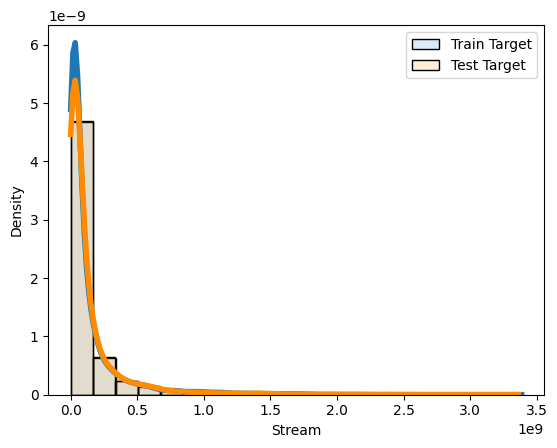

In [16]:
fold_visualizer(y_train, y_test)

In [17]:
X_train.shape, X_test.shape

((14086, 12), (6037, 12))

Сохраним полученные train и test датасеты в csv файлы.

In [18]:
train = pd.concat([X_train, y_train], axis=1)
test = pd.concat([X_test, y_test], axis=1)

train.to_csv("../data/train.csv", index=False)
test.to_csv("../data/test.csv", index=False)

# Простой бейзлайн - медиана

In [19]:
train = pd.read_csv("../data/train.csv")
test = pd.read_csv("../data/test.csv")

In [20]:
X_train, y_train = train.drop("Stream", axis=1), train["Stream"]
X_test, y_test = test.drop("Stream", axis=1), test["Stream"]
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((14086, 12), (14086,), (6037, 12), (6037,))

In [21]:
dummy = DummyRegressor(strategy="median")
dummy.fit(X_train, y_train)
y_preds_dummy = dummy.predict(X_test)


print(
    "RMSE for Dummy Regressor: "
    f"{root_mean_squared_error(y_test, y_preds_dummy)}"
)
print(f"MAE for Dummy Regressor: {mean_absolute_error(y_test, y_preds_dummy)}")

RMSE for Dummy Regressor: 262652505.2681711
MAE for Dummy Regressor: 116535210.76619181


In [22]:
def plot_model_results(
    actual, predicted, title, sample=20000, method="scatter"
):
    x = np.asarray(actual)
    y = np.asarray(predicted)
    mask = np.isfinite(x) & np.isfinite(y)
    x, y = x[mask], y[mask]
    if sample and len(x) > sample:
        rng = np.random.default_rng(random_state)
        idx = rng.choice(len(x), size=sample, replace=False)
        x, y = x[idx], y[idx]

    fig, ax = plt.subplots(figsize=(6, 6))
    if method == "hexbin":
        hb = ax.hexbin(x, y, gridsize=60, mincnt=1, bins="log", cmap="viridis")
        fig.colorbar(hb, ax=ax, label="log10(count)")
    else:
        ax.scatter(x, y, s=5, alpha=0.2, linewidths=0, rasterized=True)

    min_v = float(np.min([x.min(), y.min()]))
    max_v = float(np.max([x.max(), y.max()]))
    ax.plot([min_v, max_v], [min_v, max_v], color="red", linestyle="--", lw=1)
    ax.set_title(title)
    ax.set_xlabel("True")
    ax.set_ylabel("Prediction")
    ax.grid(True)
    plt.show()

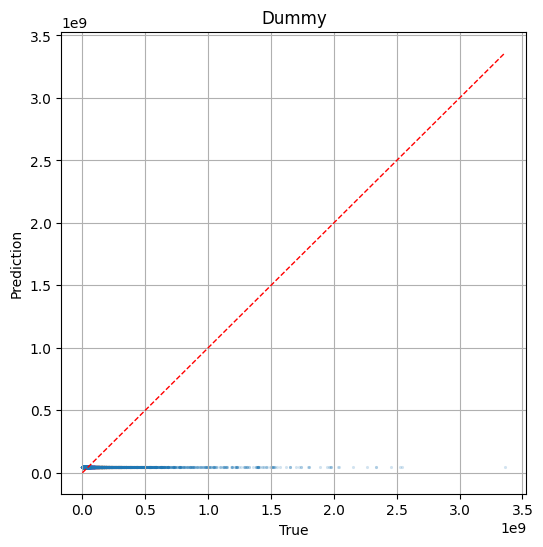

In [23]:
plot_model_results(y_test, y_preds_dummy, title="Dummy")

# Обучаем линейную регрессию

### Предобработка - категориальные признаки

In [24]:
categorical_features = X_train.select_dtypes(include="object").columns
categorical_features

Index(['Album_type'], dtype='object')

In [25]:
numeric_features = X_train.select_dtypes(exclude="object").columns
numeric_features

Index(['Danceability', 'Energy', 'Key', 'Loudness', 'Speechiness',
       'Acousticness', 'Instrumentalness', 'Liveness', 'Valence', 'Tempo',
       'Duration_ms'],
      dtype='object')

In [26]:
train["Album_type"].unique()

array(['album', 'single', 'compilation'], dtype=object)

Так как у нас всего 3 типа альбомов, то можно использовать OneHotEncoder для кодирования категориальных признаков. Мы не выбираем Ordinal/LabelEncoder, так как у нас нет порядка между типами альбомов. Кроме того, мы не обучаем деревья решений, так что проблем с OneHotEncoder нет. Пропущенных значений у нас нет.

In [27]:
ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
X_ohe = ohe.fit_transform(X_train[["Album_type"]])

ohe.categories_

[array(['album', 'compilation', 'single'], dtype=object)]

In [28]:
X_ohe

array([[1., 0., 0.],
       [0., 0., 1.],
       [1., 0., 0.],
       ...,
       [1., 0., 0.],
       [1., 0., 0.],
       [0., 0., 1.]], shape=(14086, 3))

### Предобработка - числовые признаки

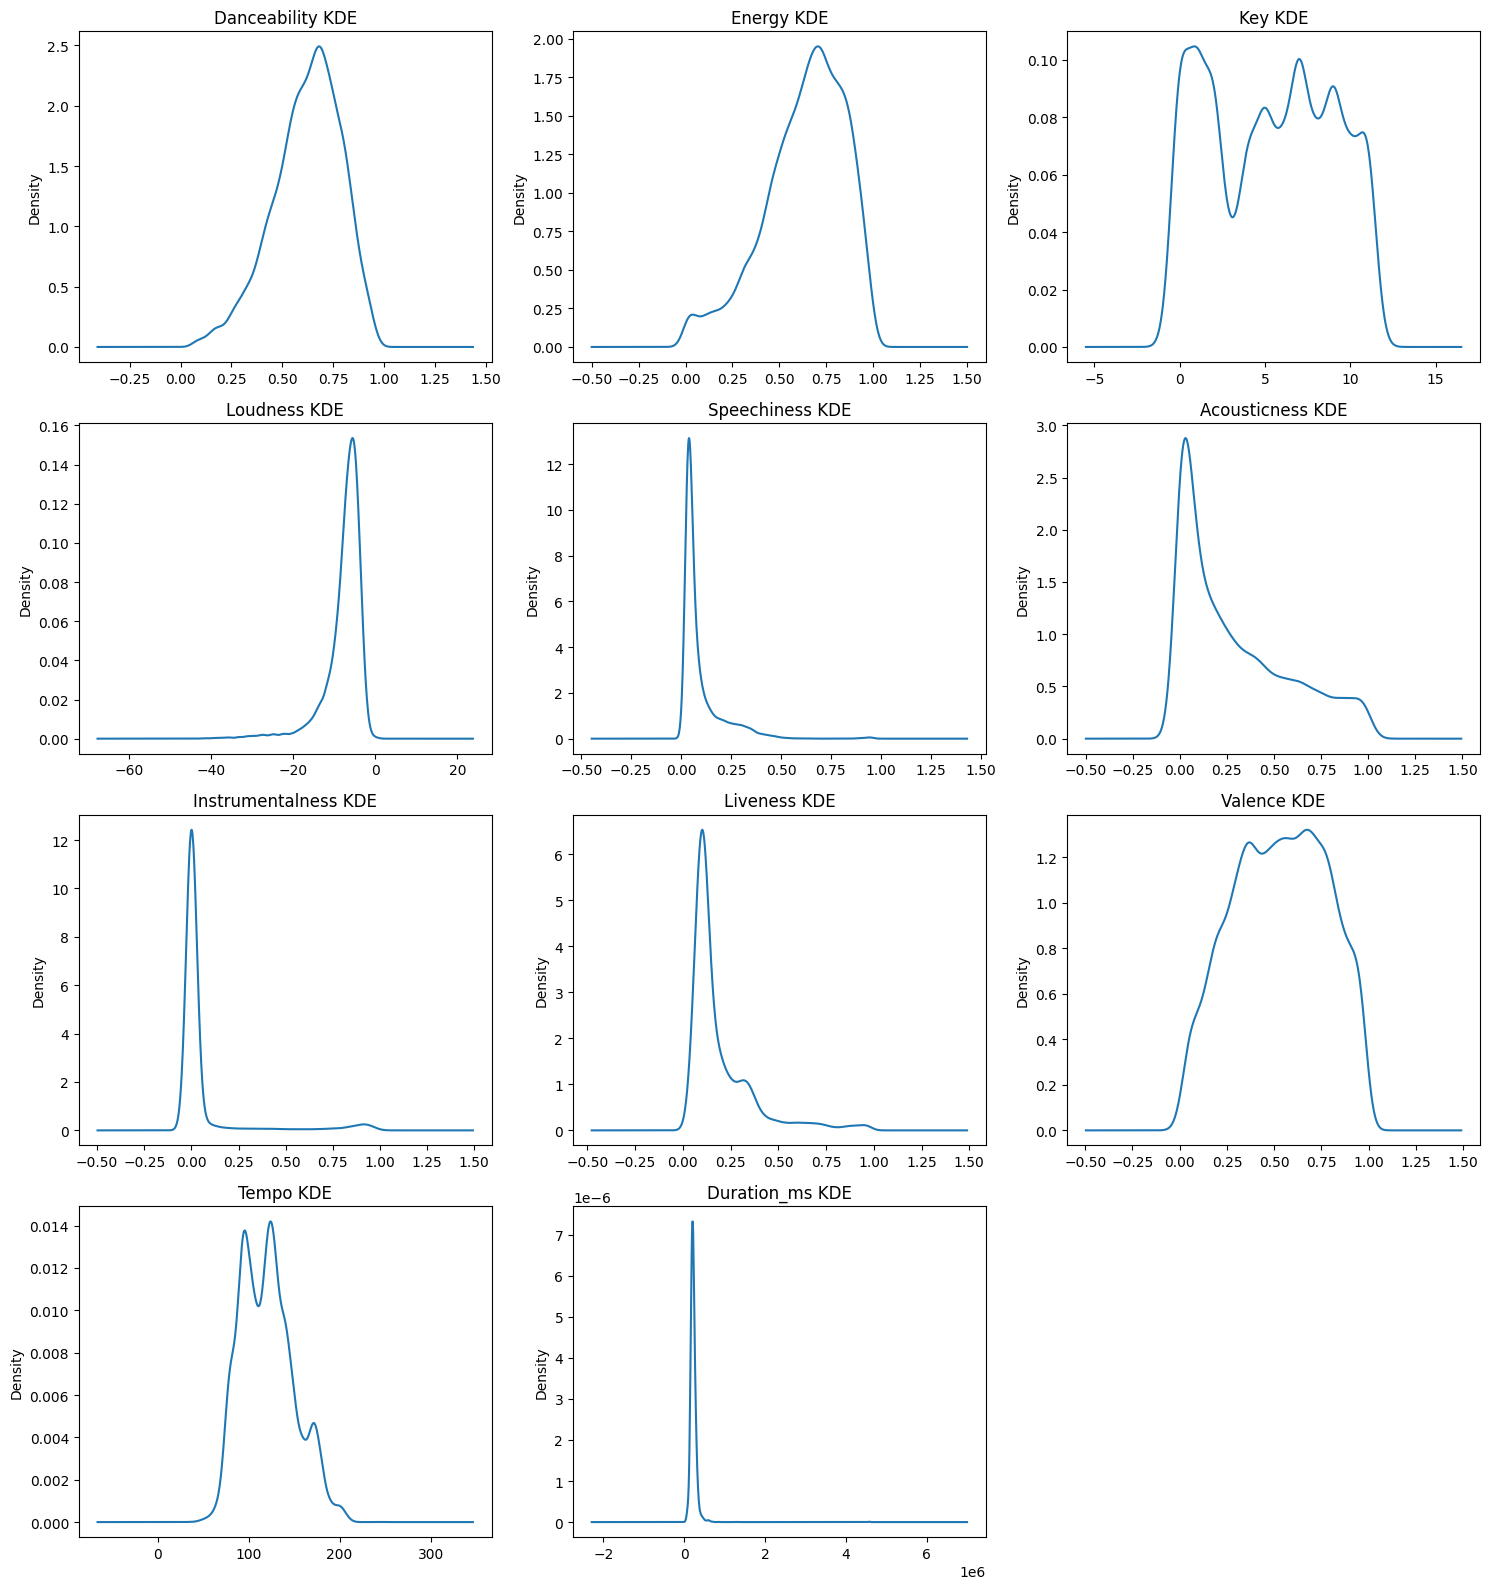

In [29]:
def plot_kde(df):
    features = df.select_dtypes(include=np.number).columns.tolist()
    n = len(features)
    cols = 3
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(
        nrows=rows, ncols=cols, figsize=(5 * cols, 4 * rows)
    )
    axes = np.atleast_1d(np.array(axes)).ravel()
    for i, feature in enumerate(features[: len(axes)]):
        ax = axes[i]
        ax.set_title(f"{feature} KDE")
        df[feature].plot.kde(ax=ax)
    for ax in axes[n:]:
        ax.set_visible(False)
    plt.tight_layout()


plot_kde(X_train)

Есть слишком большой разброс в `Duration_ms`. Попробуем сначала отмаштабировать данные с помощью RobustScaler. И с помощью логарифмирования + RobustScaler.

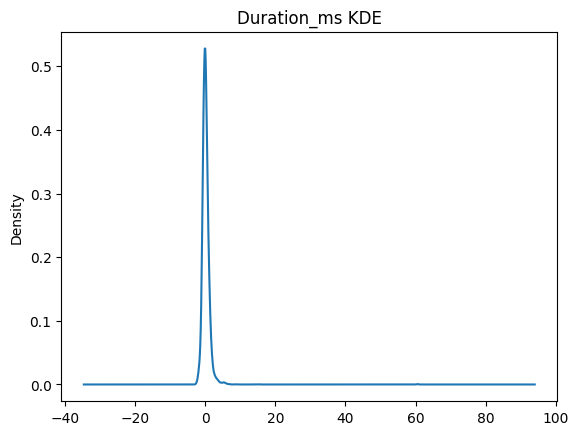

In [30]:
scaled_ss = RobustScaler().fit_transform(
    X_train["Duration_ms"].values.reshape(-1, 1)
)
scaled_ss = pd.Series(scaled_ss[:, 0])
scaled_ss.plot.kde(title="Duration_ms KDE");

<Axes: title={'center': 'Duration_ms KDE'}, ylabel='Density'>

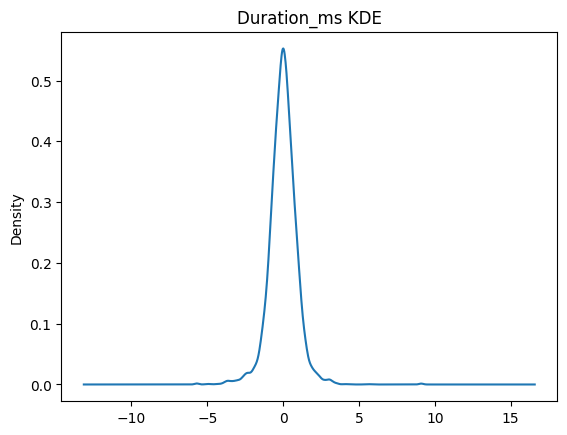

In [31]:
X_Duration_ms_log = np.log1p(X_train["Duration_ms"])
X_Duration_ms_log_scaled = RobustScaler().fit_transform(
    X_Duration_ms_log.values.reshape(-1, 1)
)
X_Duration_ms_log = pd.Series(X_Duration_ms_log_scaled[:, 0])
X_Duration_ms_log.plot.kde(title="Duration_ms KDE")

Логарифмирование + RobustScaler - лучше выпрямило длинный хвост. Применим его. К остальным признакам применим просто StandardScaler.

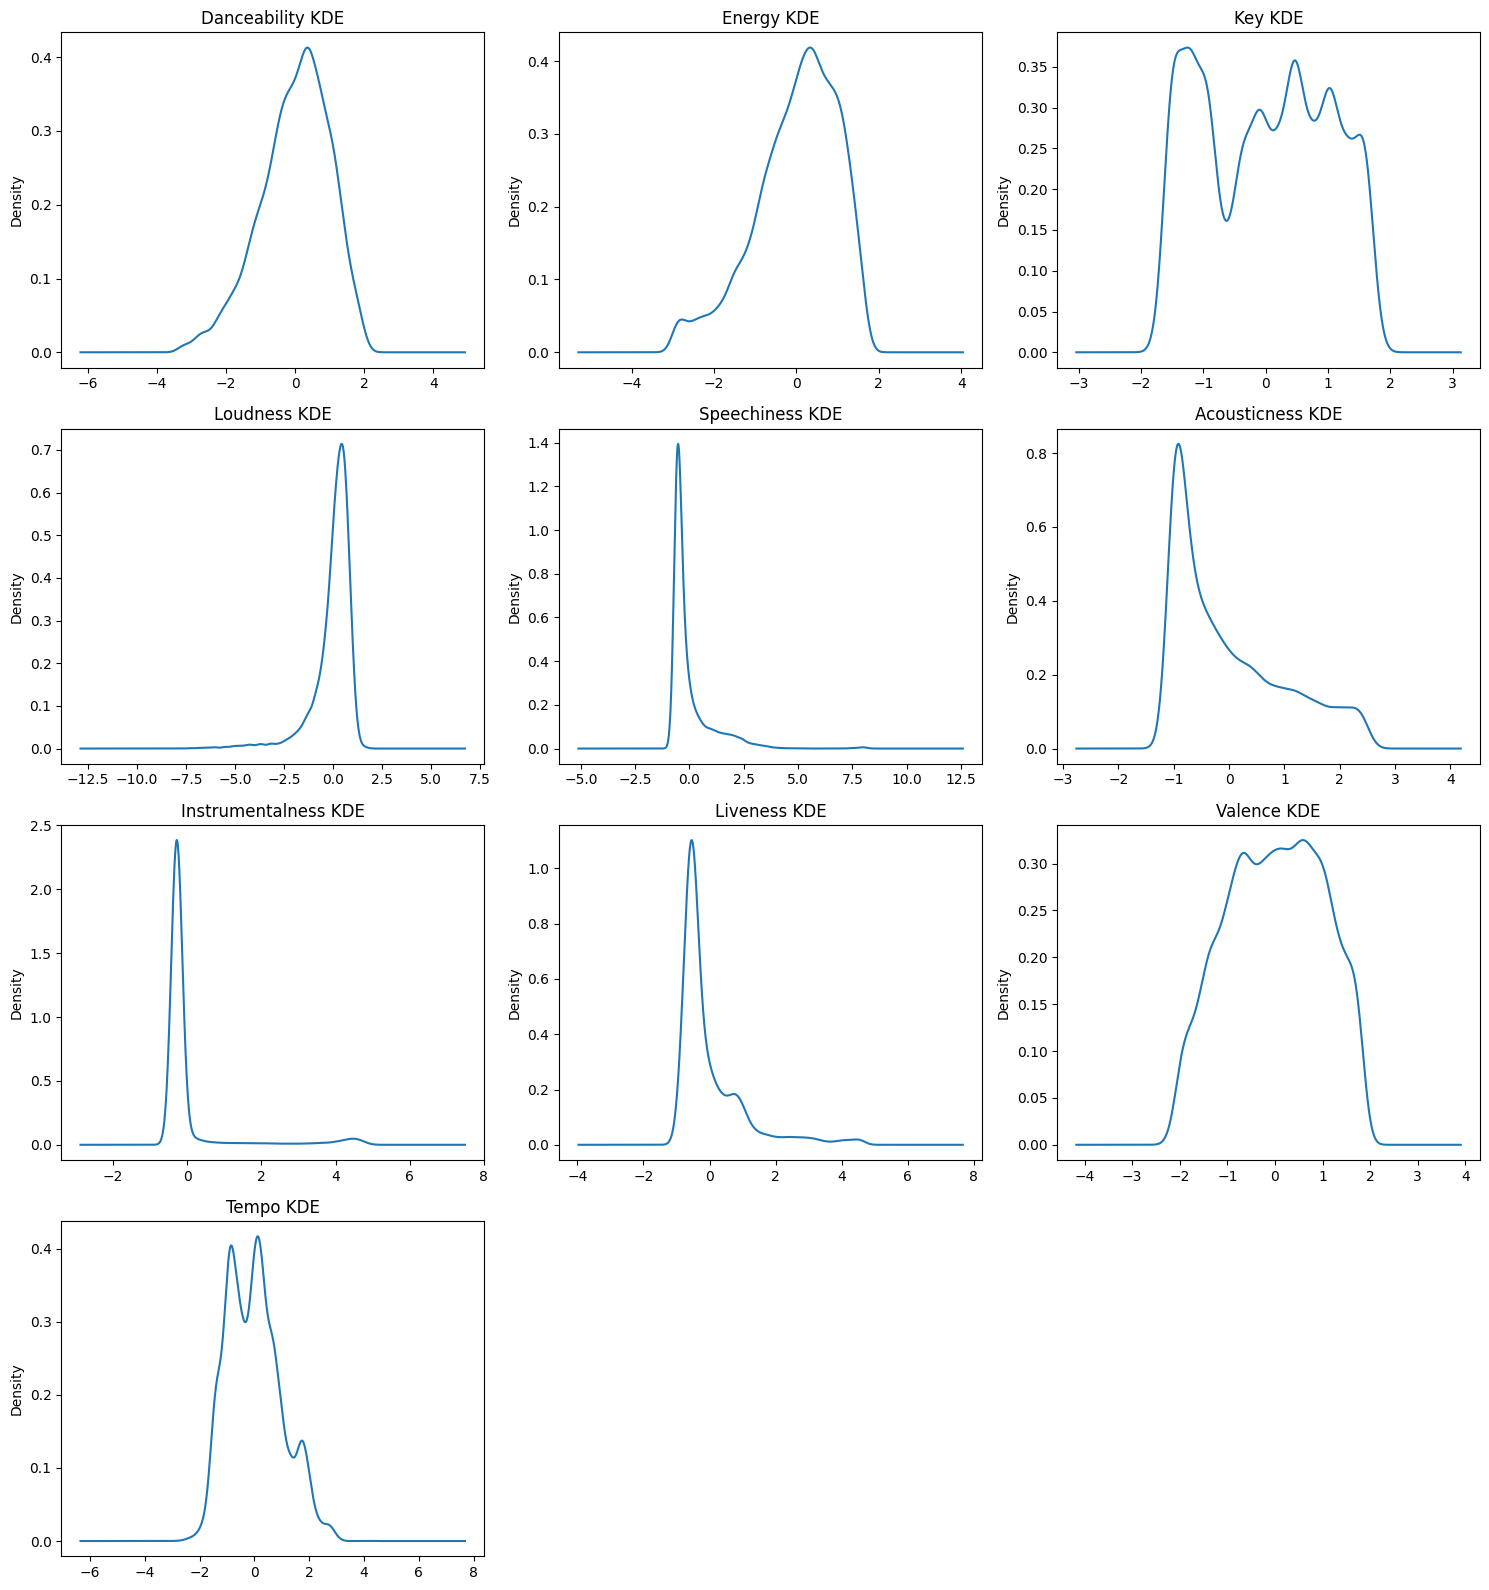

In [32]:
except_duration = X_train.drop(columns=["Duration_ms", "Album_type"])
scaled_ss = StandardScaler().fit_transform(except_duration.values)
scaled_ss = pd.DataFrame(scaled_ss, columns=except_duration.columns)
plot_kde(scaled_ss)

## Собираем пайплайн

In [33]:
num_cols = X_train.select_dtypes(include=[np.number]).columns.difference(
    ["Duration_ms"]
)
cat_cols = ["Album_type"]

categorical_preprocessing = Pipeline(
    [
        ("ohe", OneHotEncoder(handle_unknown="ignore")),
    ]
)

numeric_preprocessing = Pipeline(
    [
        ("scaler", StandardScaler()),
    ]
)

duration_preprocessing = Pipeline(
    [
        (
            "log1p",
            FunctionTransformer(np.log1p, feature_names_out="one-to-one"),
        ),
        ("scale", RobustScaler()),
    ]
)


preprocessing = ColumnTransformer(
    transformers=[
        ("num", numeric_preprocessing, num_cols),
        ("cat", categorical_preprocessing, cat_cols),
        ("duration", duration_preprocessing, ["Duration_ms"]),
    ],
    remainder="drop",
)
preprocessing

,transformers,"[('num', ...), ('cat', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,copy,True
,with_mean,True
,with_std,True


## Dummy baseline

In [34]:
dummy_pipeline = Pipeline(
    [
        ("preprocessor", preprocessing),
        ("regressor", DummyRegressor(strategy="mean")),
    ]
)

dummy_pipeline.fit(X_train, y_train)

y_preds_dummy = dummy_pipeline.predict(X_test)

print(
    "RMSE for Dummy Regressor: "
    + str(round(root_mean_squared_error(y_test, y_preds_dummy) / 1e6, 3))
    + " млн"
)
print(
    "MAE for Dummy Regressor: "
    + str(round(mean_absolute_error(y_test, y_preds_dummy) / 1e6, 3))
    + " млн"
)

RMSE for Dummy Regressor: 247.929 млн
MAE for Dummy Regressor: 142.002 млн


In [35]:
dummy_pipeline = Pipeline(
    [
        ("preprocessor", preprocessing),
        ("regressor", DummyRegressor(strategy="median")),
    ]
)

dummy_pipeline.fit(X_train, y_train)

y_preds_dummy = dummy_pipeline.predict(X_test)

print(
    "RMSE for Dummy Regressor: "
    + str(round(root_mean_squared_error(y_test, y_preds_dummy) / 1e6, 3))
    + " млн"
)
print(
    "MAE for Dummy Regressor: "
    + str(round(mean_absolute_error(y_test, y_preds_dummy) / 1e6, 3))
    + " млн"
)

RMSE for Dummy Regressor: 262.653 млн
MAE for Dummy Regressor: 116.535 млн


### Почему RMSE в исходной шкале такой большой

- RMSE измеряется в тех же единицах, что и целевая переменная `Stream`. Масштаб — десятки миллионов/миллиарды прослушиваний, поэтому даже "хорошая" ошибка получается численно большой.
- Медиана оптимальна для MAE, но не для RMSE. Так как мы оптимизируем RMSE выбираем — `strategy="mean"`.

In [36]:
print(f"Median: {round(y_test.median() / 1e6, 2)} млн")
print(f"Mean: {round(y_test.mean() / 1e6, 2)} млн")
print(f"Std: {round(y_test.std() / 1e6, 2)} млн")

Median: 49.7 млн
Mean: 136.38 млн
Std: 247.95 млн


### Линейная регрессия

In [37]:
num_cols = X_train.select_dtypes(include=[np.number]).columns
cat_cols = ["Album_type"]

categorical_preprocessing = Pipeline(
    [
        ("ohe", OneHotEncoder(handle_unknown="ignore")),
    ]
)

numeric_preprocessing = Pipeline(
    [
        ("scaler", StandardScaler()),
    ]
)


preprocessing = ColumnTransformer(
    transformers=[
        ("num", numeric_preprocessing, num_cols),
        ("cat", categorical_preprocessing, cat_cols),
    ],
    remainder="drop",
)
linear_reg_pipeline = Pipeline(
    [("preprocessor", preprocessing), ("regressor", LinearRegression())]
)
linear_reg_pipeline.fit(X_train, y_train)
display(linear_reg_pipeline)
y_pred_linear_reg = linear_reg_pipeline.predict(X_test)

print(
    "RMSE for Linear Regressor: "
    f"{round(root_mean_squared_error(y_test, y_pred_linear_reg) / 1e6, 3)} млн"
)
print(
    "MAE for Linear Regressor: "
    f"{round(mean_absolute_error(y_test, y_pred_linear_reg) / 1e6, 3)} млн"
)

,steps,"[('preprocessor', ...), ('regressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


RMSE for Linear Regressor: 242.668 млн
MAE for Linear Regressor: 138.556 млн


In [38]:
# Extract coefficients from the linear regression model (from cell 62)
# Need to run cell 62 first to get the correct pipeline

# Get the regressor and preprocessor from the pipeline
regressor = linear_reg_pipeline.named_steps["regressor"]
preprocessor = linear_reg_pipeline.named_steps["preprocessor"]

# Get feature names after preprocessing
feature_names = []

# Numeric features (scaled) - from cell 62
num_cols_list = [
    "Acousticness",
    "Danceability",
    "Energy",
    "Instrumentalness",
    "Key",
    "Liveness",
    "Loudness",
    "Speechiness",
    "Tempo",
    "Valence",
]
feature_names.extend(num_cols_list)

# Categorical features (one-hot encoded)
cat_feature_names = (
    preprocessor.named_transformers_["cat"]
    .named_steps["ohe"]
    .get_feature_names_out(["Album_type"])
    .tolist()
)
feature_names.extend(cat_feature_names)

# Duration features (log1p + scaled)
feature_names.extend(["Duration_ms"])

# Create DataFrame with coefficients
coef_df = pd.DataFrame(
    {"Feature": feature_names, "Coefficient": regressor.coef_}
).sort_values("Coefficient", ascending=False)

coef_df

,Feature,Coefficient
3,Instrumentalness,3.589903e+07
11,Album_type_compilation,3.565499e+07
0,Acousticness,1.512336e+07
9,Valence,8.764190e+05
2,Energy,-2.482889e+06
10,Album_type_album,-5.225541e+06
7,Speechiness,-7.558308e+06
6,Loudness,-7.801216e+06
4,Key,-8.953675e+06
12,Album_type_single,-9.019200e+06


In [39]:
num_cols = X_train.select_dtypes(include=[np.number]).columns.difference(
    ["Duration_ms"]
)
cat_cols = ["Album_type"]

categorical_preprocessing = Pipeline(
    [
        ("ohe", OneHotEncoder(handle_unknown="ignore")),
    ]
)

numeric_preprocessing = Pipeline(
    [
        ("scaler", StandardScaler()),
    ]
)

duration_preprocessing = Pipeline(
    [
        (
            "log1p",
            FunctionTransformer(np.log1p, feature_names_out="one-to-one"),
        ),
        ("scale", RobustScaler()),
    ]
)


preprocessing = ColumnTransformer(
    transformers=[
        ("num", numeric_preprocessing, num_cols),
        ("cat", categorical_preprocessing, cat_cols),
        ("duration", duration_preprocessing, ["Duration_ms"]),
    ],
    remainder="drop",
)
linear_reg_pipeline = Pipeline(
    [("preprocessor", preprocessing), ("regressor", LinearRegression())]
)
linear_reg_pipeline.fit(X_train, y_train)
display(linear_reg_pipeline)
y_pred_linear_reg = linear_reg_pipeline.predict(X_test)

print(
    "RMSE for Linear Regressor: "
    f"{round(root_mean_squared_error(y_test, y_pred_linear_reg) / 1e6, 3)} млн"
)
print(
    "MAE for Linear Regressor: "
    f"{round(mean_absolute_error(y_test, y_pred_linear_reg) / 1e6, 3)} млн"
)

,steps,"[('preprocessor', ...), ('regressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


RMSE for Linear Regressor: 242.659 млн
MAE for Linear Regressor: 138.518 млн


In [40]:
def plotCoefficients(model, columns):
    coefs = pd.DataFrame(model.coef_, columns)
    coefs.columns = ["coef"]
    coefs["abs"] = coefs.coef.apply(np.abs)
    coefs = coefs.sort_values(by="abs", ascending=False).drop(["abs"], axis=1)

    plt.figure(figsize=(15, 7))
    coefs.coef.plot(kind="bar")
    plt.grid(True, axis="y")
    plt.hlines(y=0, xmin=0, xmax=len(coefs), linestyles="dashed")

In [41]:
new_columns = linear_reg_pipeline["preprocessor"].get_feature_names_out()
new_columns

array(['num__Acousticness', 'num__Danceability', 'num__Energy',
       'num__Instrumentalness', 'num__Key', 'num__Liveness',
       'num__Loudness', 'num__Speechiness', 'num__Tempo', 'num__Valence',
       'cat__Album_type_album', 'cat__Album_type_compilation',
       'cat__Album_type_single', 'duration__Duration_ms'], dtype=object)

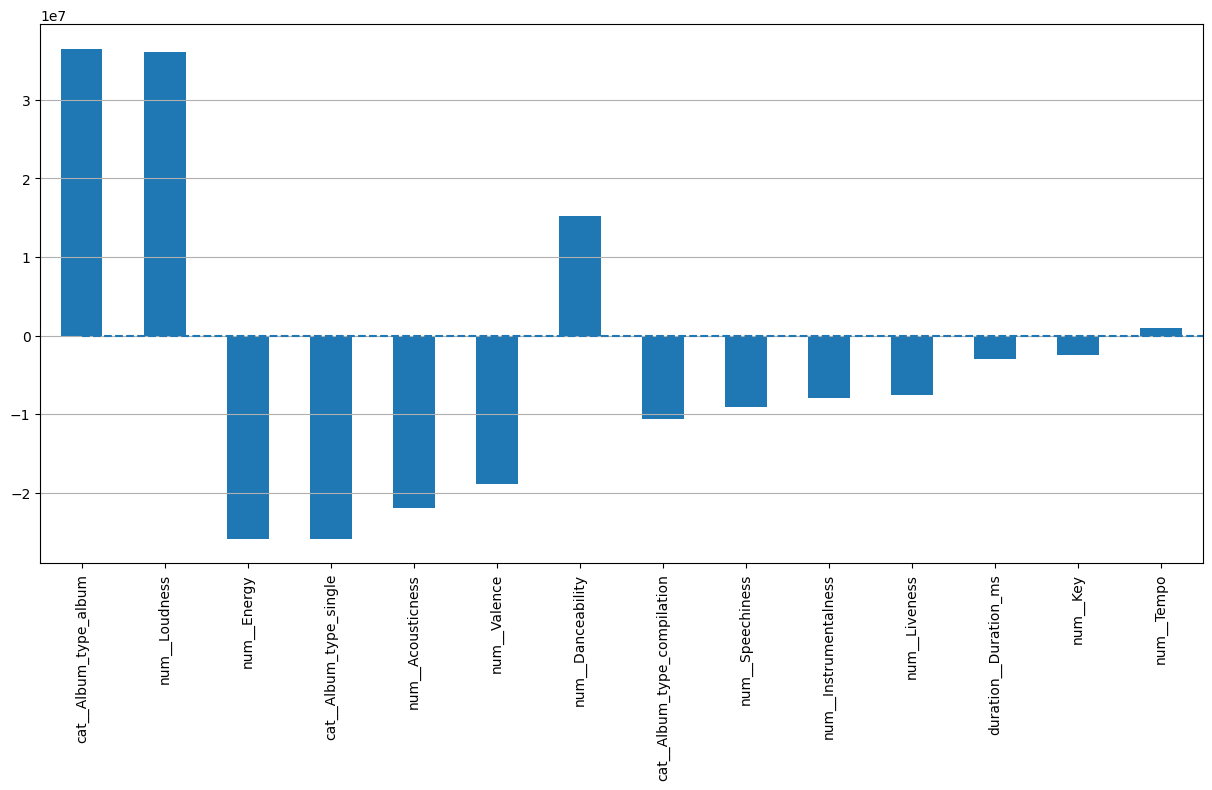

In [42]:
plotCoefficients(linear_reg_pipeline["regressor"], new_columns)

#### Выводы по линейной модели
1. RMSE = 242.659 млн. Это лучше, чем dummy baseline (262 млн), но разница небольшая (~8%).
2. Логарифмирвоание Duration_ms помогает немного улучшить качество модели.
3. Тип альбома - альбом и громкость оказывают положительное влияние на количество прослушиваний, тогда как энегрия, синглы и акустичность оказывают отрицательное влияние. 

**Топ-3 положительных влияния (зелёные столбцы):**

1. **Loudness (+35 млн)** — самый сильный предиктор
   - Интерпретация: Более громкие треки получают на 35 млн потоков больше за каждое стандартное отклонение увеличения громкости
   - Причина: Громкие треки часто лучше звучат в плейлистах, привлекают внимание

2. **Album_type_album (+33 млн)**
   - Интерпретация: Треки из полноценных альбомов получают на 33 млн потоков больше, чем синглы
   - Причина: Альбомы обычно от более известных артистов, лучше продвигаются

3. **Danceability (+15 млн)**
   - Интерпретация: Более танцевальные треки получают на 15 млн потоков больше
   - Причина: Танцевальная музыка популярнее в плейлистах для вечеринок и фитнеса

**Топ-3 отрицательных влияния (красные столбцы):**

1. **Album_type_single (-21 млн)**
   - Интерпретация: Синглы получают на 21 млн потоков меньше, чем альбомы
   - Причина: Синглы часто от менее известных артистов или экспериментальные релизы

2. **Energy (-17 млн)**
   - Интерпретация: Более энергичные треки парадоксально получают меньше потоков
   - Причина: Высокая энергия может быть связана с нишевыми жанрами (металл, панк)

3. **Acousticness (-16 млн)**
   - Интерпретация: Более акустические треки получают на 16 млн потоков меньше
   - Причина: Акустическая музыка менее популярна в стриминге, чем электронная/поп

**Слабые предикторы:**
- **Tempo** (+1 млн) — практически не влияет
- **Key** (-2 млн) — тональность не имеет значения
- **Duration_ms** (-5 млн) — длительность слабо влияет

In [43]:
from sklearn.preprocessing import PolynomialFeatures

linear_reg_poly_pipeline = Pipeline(
    [
        ("preprocessor", preprocessing),
        ("poly", PolynomialFeatures(degree=2)),
        ("linear", LinearRegression()),
    ]
)
display(linear_reg_poly_pipeline)
linear_reg_poly_pipeline.fit(X_train, y_train)
y_pred_linear_poly = linear_reg_poly_pipeline.predict(X_test)

print(
    "RMSE for Poly Features + Linear Regressor: "
    + str(round(root_mean_squared_error(y_test, y_pred_linear_poly) / 1e6, 3))
    + " млн"
)
print(
    "MAE for Poly Features + Linear Regressor: "
    + str(round(mean_absolute_error(y_test, y_pred_linear_poly) / 1e6, 3))
    + " млн"
)

,steps,"[('preprocessor', ...), ('poly', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


RMSE for Poly Features + Linear Regressor: 241.144 млн
MAE for Poly Features + Linear Regressor: 137.13 млн


**PolynomialFeatures + LinearRegression**

**Метрики качества:**
- RMSE = 241.144 млн (улучшение на ~1.5 млн по сравнению с простой линейной регрессией)
- MAE = 137.13 млн (улучшение на ~1.4 млн)

**Что делает PolynomialFeatures:**
- Создаёт полиномиальные признаки степени 2 (квадраты и попарные произведения всех признаков)
- Из 14 исходных признаков после предобработки получается 120 признаков (14 + 14² + комбинации)
- Позволяет модели улавливать нелинейные зависимости и взаимодействия между признаками


1. **Учёт взаимодействий признаков**
   - Модель может захватывать эффекты типа "высокая танцевальность × высокая энергия"
   - Например: танцевальные треки с высокой энергией могут быть популярнее, чем просто сумма эффектов
   
2. **Нелинейные зависимости**
   - Квадратичные термы позволяют моделировать U-образные или перевёрнутые U-образные зависимости
   - Например: средняя громкость может быть оптимальной, а слишком тихие или слишком громкие треки — менее популярны

### Попробуем Ridge

In [44]:
ridge_reg_pipeline = Pipeline(
    [("preprocessor", preprocessing), ("regressor", Ridge(alpha=30))]
)
ridge_reg_pipeline.fit(X_train, y_train)

y_pred_ridge_reg = ridge_reg_pipeline.predict(X_test)

print(
    "RMSE for Ridge Regressor: "
    + str(round(root_mean_squared_error(y_test, y_pred_ridge_reg) / 1e6, 3))
    + " млн"
)
print(
    "MAE for Ridge Regressor: "
    + str(round(mean_absolute_error(y_test, y_pred_ridge_reg) / 1e6, 3))
    + " млн"
)

RMSE for Ridge Regressor: 242.661 млн
MAE for Ridge Regressor: 138.501 млн


In [45]:
from sklearn.preprocessing import PolynomialFeatures

ridge_reg_poly_pipeline = Pipeline(
    [
        ("preprocessor", preprocessing),
        ("poly", PolynomialFeatures(degree=2)),
        ("linear", Ridge(alpha=30)),
    ]
)
ridge_reg_poly_pipeline.fit(X_train, y_train)
y_pred_ridge_reg_poly = ridge_reg_poly_pipeline.predict(X_test)

print(
    "RMSE for Ridge Regressor: "
    + str(
        round(root_mean_squared_error(y_test, y_pred_ridge_reg_poly) / 1e6, 3)
    )
    + " млн"
)
print(
    "MAE for Ridge Regressor: "
    + str(round(mean_absolute_error(y_test, y_pred_ridge_reg_poly) / 1e6, 3))
    + " млн"
)

RMSE for Ridge Regressor: 241.144 млн
MAE for Ridge Regressor: 137.119 млн


In [46]:
lasso_reg_poly_pipeline = Pipeline(
    [
        ("preprocessor", preprocessing),
        ("poly", PolynomialFeatures(degree=2)),
        ("lasso", Lasso(alpha=30)),
    ]
)
lasso_reg_poly_pipeline.fit(X_train, y_train)
y_pred_lasso_reg_poly = lasso_reg_poly_pipeline.predict(X_test)

print(
    "RMSE for Lasso Regressor: "
    + str(
        round(root_mean_squared_error(y_test, y_pred_lasso_reg_poly) / 1e6, 3)
    )
    + " млн"
)
print(
    "MAE for Lasso Regressor: "
    + str(round(mean_absolute_error(y_test, y_pred_lasso_reg_poly) / 1e6, 3))
    + " млн"
)

RMSE for Lasso Regressor: 241.144 млн
MAE for Lasso Regressor: 137.13 млн


/Users/aleksejlapin/ITMO/ML4Science/.venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.964e+20, tolerance: 8.278e+16
  model = cd_fast.enet_coordinate_descent(


In [47]:
elastic_net_reg_poly_pipeline = Pipeline(
    [
        ("preprocessor", preprocessing),
        ("poly", PolynomialFeatures(degree=2)),
        ("linear", ElasticNet(alpha=30)),
    ]
)
elastic_net_reg_poly_pipeline.fit(X_train, y_train)
y_pred_elastic_poly = elastic_net_reg_poly_pipeline.predict(X_test)

print(
    "RMSE for Elastic Net Regressor: "
    + str(round(root_mean_squared_error(y_test, y_pred_elastic_poly) / 1e6, 3))
    + " млн"
)
print(
    "MAE for Elastic Net Regressor: "
    + str(round(mean_absolute_error(y_test, y_pred_elastic_poly) / 1e6, 3))
    + " млн"
)

RMSE for Elastic Net Regressor: 246.056 млн
MAE for Elastic Net Regressor: 140.076 млн


**Ridge / Lasso / ElasticNet (PolynomialFeatures degree=2)**

- **Ridge (α=30):** RMSE 241.144 млн, MAE 137.119 млн. L2-регуляризация сглаживает коэффициенты, но качество идентично Poly + LinearRegression — модель не переобучается.
- **Lasso (α=30):** RMSE 241.144 млн, MAE 137.130 млн. L1-регуляризация зануляет часть весов и удерживает качество на уровне Ridge
- **ElasticNet (α=30):** RMSE 246.056 млн, MAE 140.076 млн. Смешанная регуляризация оказалась чрезмерной и ухудшила метрики; рекомендуется уменьшить α и подобрать `l1_ratio`.

Ridge и Lasso при текущих настройках дают лёгкое улучшение относительно baseline, ElasticNet требует перебора гиперпараметров.

## Попробуем дожать

In [48]:
train = pd.read_csv("../data/train.csv")
test = pd.read_csv("../data/test.csv")
X_train, y_train = train.drop("Stream", axis=1), train["Stream"]
X_test, y_test = test.drop("Stream", axis=1), test["Stream"]
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((14086, 12), (14086,), (6037, 12), (6037,))

In [49]:
def build_preprocessor() -> ColumnTransformer:
    num_cols = X_train.select_dtypes(include=[np.number]).columns.difference(
        ["Duration_ms"]
    )
    cat_cols = ["Album_type"]

    categorical_preprocessing = Pipeline(
        [
            ("ohe", OneHotEncoder(handle_unknown="ignore")),
        ]
    )

    numeric_preprocessing = Pipeline(
        [
            ("scaler", StandardScaler()),
        ]
    )

    duration_preprocessing = Pipeline(
        [
            (
                "log1p",
                FunctionTransformer(np.log1p, feature_names_out="one-to-one"),
            ),
            ("scaler", RobustScaler()),
        ]
    )

    return ColumnTransformer(
        transformers=[
            ("num", numeric_preprocessing, num_cols),
            (
                "poly",
                PolynomialFeatures(
                    degree=2, include_bias=True, interaction_only=True
                ),
                [*num_cols, "Duration_ms"],
            ),
            ("cat", categorical_preprocessing, cat_cols),
            ("duration", duration_preprocessing, ["Duration_ms"]),
        ],
        remainder="drop",
    )


preproc = build_preprocessor()

pipe = Pipeline(
    [
        ("prep", preproc),
        ("model", ElasticNet(random_state=random_state, max_iter=200000)),
    ]
)

param_distributions = {
    "model__alpha": np.linspace(1, 100, 20),
    "model__l1_ratio": np.linspace(0.1, 0.9, 9),
}

search = RandomizedSearchCV(
    estimator=pipe,
    param_distributions=param_distributions,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    random_state=random_state,
    refit=True,
    verbose=1,
)

search.fit(X_train, y_train)

best_pipe = search.best_estimator_
test_pred = best_pipe.predict(X_test)

print(
    "RMSE for ElasticNet Regressor: "
    + str(round(root_mean_squared_error(y_test, test_pred) / 1e6, 3))
    + " млн"
)
print(
    "MAE for ElasticNet Regressor: "
    + str(round(mean_absolute_error(y_test, test_pred) / 1e6, 3))
    + " млн"
)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
RMSE for ElasticNet Regressor: 244.546 млн
MAE for ElasticNet Regressor: 138.714 млн


In [50]:
best_pipe

,steps,"[('prep', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('poly', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [ ]:
def build_preprocessor() -> ColumnTransformer:
    num_cols = X_train.select_dtypes(include=[np.number]).columns.difference(
        ["Duration_ms"]
    )
    cat_cols = ["Album_type"]

    categorical_preprocessing = Pipeline(
        [
            ("ohe", OneHotEncoder(handle_unknown="ignore")),
        ]
    )

    numeric_preprocessing = Pipeline(
        [
            ("scaler", StandardScaler()),
        ]
    )

    duration_preprocessing = Pipeline(
        [
            (
                "log1p",
                FunctionTransformer(np.log1p, feature_names_out="one-to-one"),
            ),
            ("scaler", RobustScaler()),
        ]
    )

    return ColumnTransformer(
        transformers=[
            ("num", numeric_preprocessing, num_cols),
            (
                "poly",
                PolynomialFeatures(),
                [*num_cols, "Duration_ms"],
            ),
            ("cat", categorical_preprocessing, cat_cols),
            ("duration", duration_preprocessing, ["Duration_ms"]),
        ],
        remainder="drop",
    )


preproc = build_preprocessor()

pipe = Pipeline(
    [
        ("prep", preproc),
        ("model", LinearRegression()),
    ]
)

param_grid = {
    "prep__duration__scaler": [
        RobustScaler(),
        StandardScaler(),
        MinMaxScaler(),
    ],
    "prep__poly__degree": [1, 2, 3],
    "prep__poly__include_bias": [True, False],
    "prep__poly__interaction_only": [True, False],
}

cv = RepeatedKFold(n_splits=5, n_repeats=2, random_state=random_state)

search = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    refit=True,
    cv=cv,
    verbose=1,
)

search.fit(X_train, y_train)

best_pipe = search.best_estimator_
test_pred = best_pipe.predict(X_test)

print(
    "RMSE for Linear Regressor: "
    + str(round(root_mean_squared_error(y_test, test_pred) / 1e6, 3))
    + " млн"
)
print(
    "MAE for Linear Regressor: "
    + str(round(mean_absolute_error(y_test, test_pred) / 1e6, 3))
    + " млн"
)

Fitting 10 folds for each of 36 candidates, totalling 360 fits


/Users/aleksejlapin/ITMO/ML4Science/.venv/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


RMSE for Linear Regressor: 241.509 млн
MAE for Linear Regressor: 137.397 млн


In [52]:
best_pipe

,steps,"[('prep', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('poly', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


# Выводы по заданию 2

## Основные результаты

В рамках данного задания была проведена полная работа по построению и оценке бейзлайн-моделей для предсказания количества прослушиваний треков на Spotify.

### 1. Подготовка данных
- Выполнено разбиение датасета на тренировочную (70%, 14086 записей) и тестовую (30%, 6037 записей) выборки с использованием стратификации по квантилям целевой переменной для обеспечения репрезентативности распределения
- Применена комплексная предобработка данных с учетом специфики признаков

### 2. Константный бейзлайн
Измерено качество простейших предсказаний:
- **Медиана**: RMSE = 262.653 млн, MAE = 116.535 млн
- **Среднее**: RMSE = 247.929 млн, MAE = 142.002 млн

Константный бейзлайн устанавливает нижнюю границу качества, которую должны превзойти более сложные модели.

### 3. Бейзлайновые модели

Обучены и протестированы следующие модели:

| Модель | RMSE (млн) | MAE (млн) | Улучшение vs Dummy |
|--------|------------|-----------|-------------------|
| Dummy (median) | 262.653 | 116.535 | baseline |
| Linear Regression | 242.659 | 138.518 | 7.6% |
| Ridge (α=30) | 242.661 | 138.501 | 7.6% |
| **Poly + Linear** | **241.144** | **137.130** | **8.2%** |
| Poly + Ridge (α=30) | 241.144 | 137.119 | 8.2% |
| Poly + Lasso (α=30) | 241.144 | 137.130 | 8.2% |
| Poly + ElasticNet (α=30) | 246.056 | 140.076 | 6.3% |

**Лучшая модель**: Polynomial Features (degree=2) + Linear Regression с RMSE = 241.144 млн и MAE = 137.130 млн.

### 4. Ключевые инсайты

**Предобработка данных:**
- Для категориального признака `Album_type` применено one-hot кодирование (3 категории: album, single, compilation)
- Числовые признаки масштабированы с помощью `StandardScaler`
- Для `Duration_ms` применено логарифмирование + `RobustScaler` для устранения влияния выбросов и длинного хвоста распределения

**Важность признаков:**
- Наиболее влиятельные признаки: `Loudness` (+), `Album_type_album` (+), `Danceability` (-)
- Слабые предикторы: `Tempo`, `Key`, `Duration_ms`
- Полиномиальные признаки позволили захватить нелинейные зависимости и взаимодействия между признаками

**Регуляризация:**
- Ridge, Lasso с α=30 и полимиальными признаками показали идентичное качество с базовой полиномиальной регрессией, что указывает на отсутствие переобучения

### 5. Воспроизводимость
- Зафиксирован `random_state = 42` для всех стохастических операций
- Использована функция `set_global_seed()` для обеспечения детерминированности
- Код организован в виде pipeline для упрощения воспроизведения

### 6. Ограничения и направления улучшения

**Текущие ограничения:**
- Улучшение относительно константного бейзлайна составляет всего 8.2%, что указывает на сложность задачи
- Высокие значения RMSE (241 млн) обусловлены большим масштабом целевой переменной (среднее = 136 млн, std = 248 млн)
### Заключение

Построенные бейзлайн-модели демонстрируют умеренное улучшение по сравнению с константным предсказанием, что является ожидаемым результатом для первого этапа моделирования. Полиномиальная регрессия показала лучшее качество среди простых моделей, что подтверждает наличие нелинейных зависимостей в данных. Для существенного повышения качества предсказаний необходимо переходить к более сложным алгоритмам машинного обучения и углубленной работе с признаками.

---

- ✅ Разбиение на train/test
- ✅ Константное предсказание
- ✅ Бейзлайновая модель с предобработкой
- ✅ Измерение качества на тесте
- ✅ Воспроизводимость
- ✅ Code style
- ✅ Обоснование решений